In [30]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import matplotlib.cm as cm
from io import StringIO
import sys
import nc_time_axis
import os
import cftime

sys.path.append('C:\\Users\\madel\\Code\\GeoNorth')

import utils

import importlib
importlib.reload(utils)

# This just suppresses warnings to make outputs look nicer
import warnings
warnings.filterwarnings('ignore')

In [39]:
def RMSE_by_depth(tsoi_rmse_da, deep, target):
    month_order = [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
    month_labels = ["S", "O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A"]
    figs, (ax1, ax2) = plt.subplots(1,2, width_ratios=[2, 1], figsize=(8, 5))
    for x in deep:
        #print(x)
        #print(tsoi_rmse_da["RMSE_monthly"].sel(depth = x).values)
        ax1.scatter(month_order,tsoi_rmse_da["RMSE_monthly"].sel(depth = x))
        ax2.scatter(1, tsoi_rmse_da["RMSE_full"].sel(depth=x))
    ax1.set_xticks(month_order, month_labels)
    ax2.set_xticks([0,1,2],[" ", "AVG", " "])
    ax2.legend(deep)
    plt.title("RMSE by depths")
    plt.show()

    return tsoi_rmse_da["RMSE_full"].sel(depth=target, method="nearest").item()
    
    

In [ ]:
def RMSE_per_site(tsoi_rmse_da, deep):

    fig, ax = plt.subplots()

    fruits = ['apple', 'blueberry', 'cherry', 'orange']
    counts = [40, 100, 30, 55]
    bar_labels = ['red', 'blue', '_red', 'orange']
    bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange']

    ax.bar(fruits, counts, label=bar_labels, color=bar_colors)

    ax.set_ylabel('fruit supply')
    ax.set_title('Fruit supply by kind and color')
    ax.legend(title='Fruit color')

    plt.show()

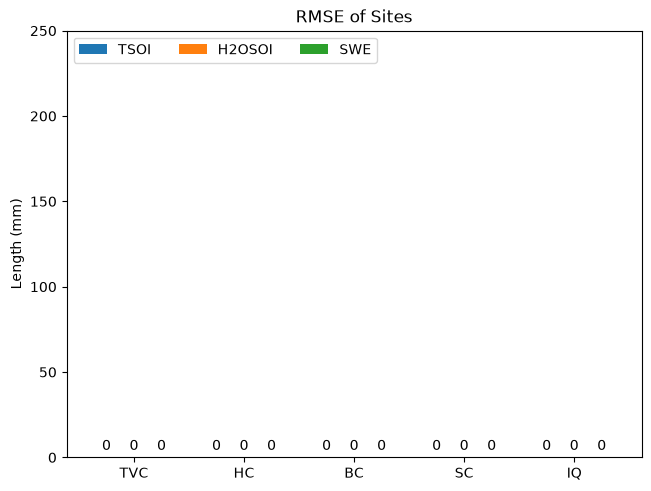

In [41]:
RMSE_per_site(1,2)

# Full Process Run - Just TSOI

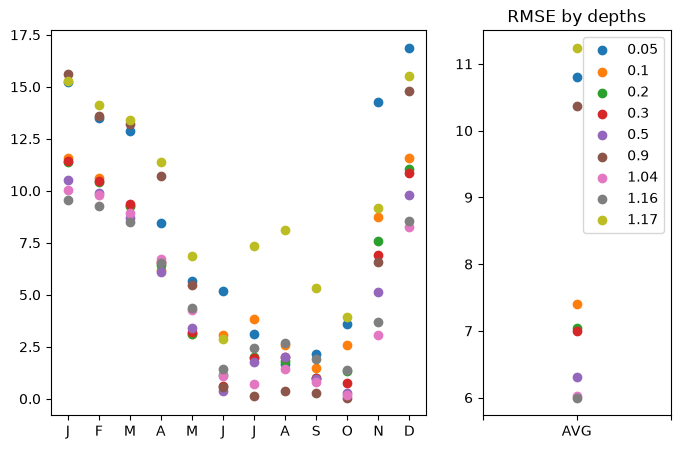

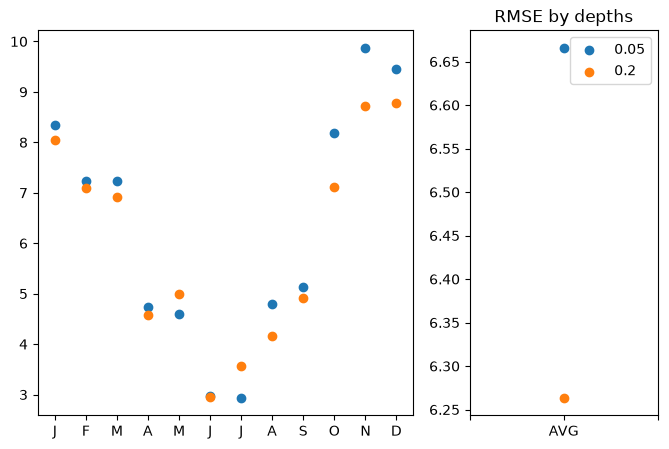

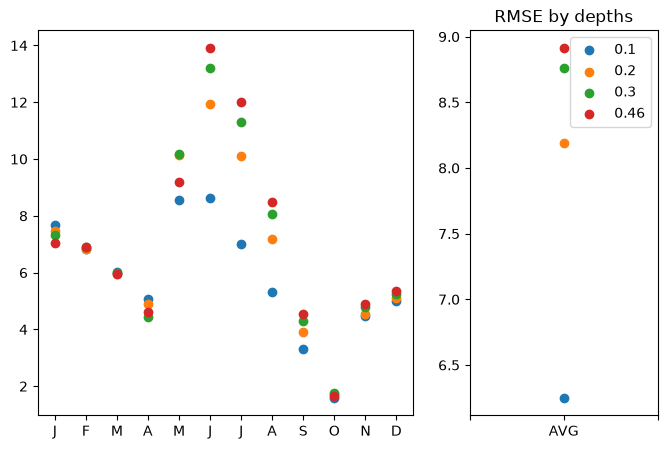

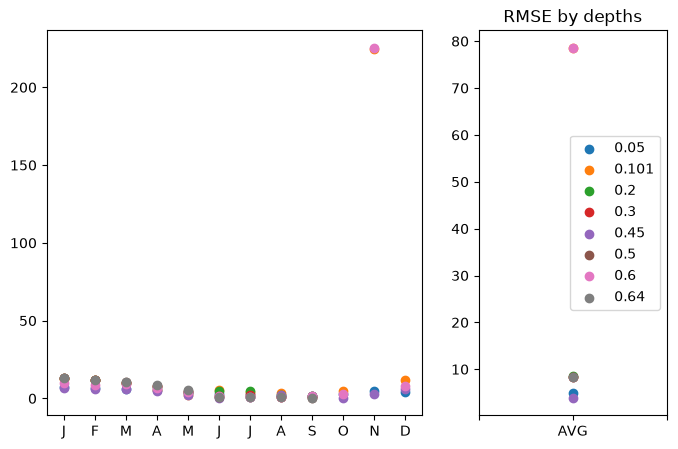

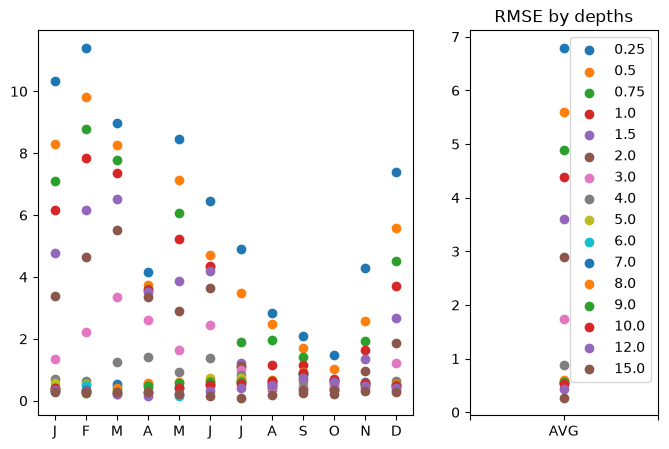

[7.401001070417173, 6.665717447116112, 6.249744296186107, 8.99708010561539, 6.79308288926155]


: 

In [ ]:
sites = ("TVC", "SC", "BC", "HC", "IQ")

def is_not_empty_listdir(path):
    return not len(os.listdir(path)) == 0

RMSE = []

for site in sites:
    
    # pull ctsm file
    ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"
    df = xr.open_dataset(ctsm_file, engine="netcdf4")

    # starting with TSOI
    vari = "TSOI"

    if is_not_empty_listdir(f"C:\\Users\\madel\\Code\\GeoNorth\\Observational_data\\{site}_obs\\raw\\{vari}"):
        ds = xr.open_dataset(f"../Observational_data/{site}_obs/processed/{site}_{vari}.nc")


        # sort for variables
        ds_ctsm = df[f"{vari}"]
        ds_obs = ds[f"{vari}"]
        ds_obs = ds_obs.sortby("depth")

        # Interpolate ctsm data
        da_interp = utils.interpolate_to_depth(df, ds_obs.depth)

        # Plots
        tsoi_rmse_da = utils.final_plot_tsoi(da_interp, f"{site}", ds_obs.depth, f"{vari}")


        used = utils.clean_august_profile_tsoi(ds_obs, ds_ctsm, site, ds_obs.depth, f"{vari}")

        target_RMSE = RMSE_by_depth(tsoi_rmse_da, used, 0.1)
        RMSE.append(target_RMSE)

        #utils.single_seasonal_cycle_tsoi(ds_obs, da_interp, site, used, vari)
        #utils.seasonal_plot_tsoi(ds_obs, da_interp, site, ds_obs.depth, f"{vari}")

print(RMSE)

In [ ]:
tsoi_rmse_da["RMSE_full"].depth.values

array([ 0.25,  0.5 ,  0.75,  1.  ,  1.5 ,  2.  ,  3.  ,  4.  ,  5.  ,
        6.  ,  7.  ,  8.  ,  9.  , 10.  , 12.  , 15.  ])

Making RMSE plot

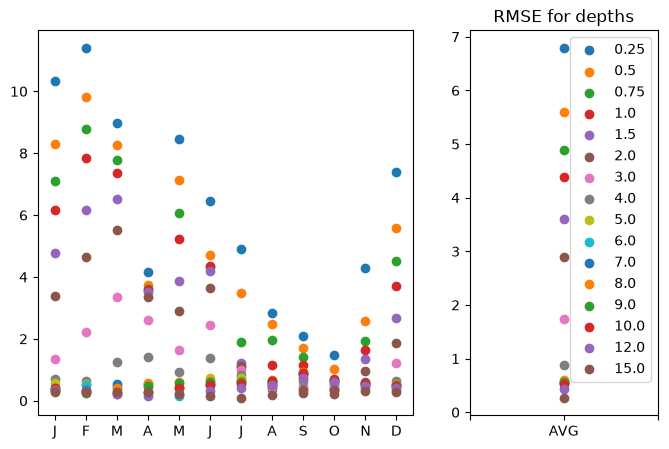

In [ ]:
month_order = [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
month_labels = ["S", "O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A"]
figs, (ax1, ax2) = plt.subplots(1,2, width_ratios=[2, 1], figsize=(8, 5))
for x in tsoi_rmse_da.depth:
    ax1.scatter(month_order,tsoi_rmse_da["RMSE_monthly"].sel(depth = x))
    ax2.scatter(1, tsoi_rmse_da["RMSE_full"].sel(depth=x))
ax1.set_xticks(month_order, month_labels)
ax2.set_xticks([0,1,2],[" ", "AVG", " "])
ax2.legend(tsoi_rmse_da["RMSE_full"].depth.values)
plt.title("RMSE for depths")
plt.show()

Moving on to RMSE per site